In [2]:
# IMPORT LIBRARIES 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

print("FIXING MODEL OVERFITTING - REMOVING TIME DATA LEAKAGE")

FIXING MODEL OVERFITTING - REMOVING TIME DATA LEAKAGE


In [3]:
#  LOAD DATA 
train_path = r"D:\bhopal-pollutant-prediction\processed_data\train_engineered.csv"
test_path = r"D:\bhopal-pollutant-prediction\processed_data\test_engineered.csv"

train = pd.read_csv(train_path, parse_dates=['datetime'], index_col='datetime')
test = pd.read_csv(test_path, parse_dates=['datetime'], index_col='datetime')

print(" LOADED DATA:")
print(f"Train shape: {train.shape} | Dates: {train.index.min()} to {train.index.max()}")
print(f"Test shape:  {test.shape} | Dates: {test.index.min()} to {test.index.max()}")
print(f"Total columns: {train.shape[1]}")

 LOADED DATA:
Train shape: (13632, 184) | Dates: 2024-01-01 00:00:00 to 2025-07-21 23:00:00
Test shape:  (3408, 184) | Dates: 2025-07-22 00:00:00 to 2025-12-10 23:00:00
Total columns: 184


In [4]:
#  UNDERSTANDING THE OVERFITTING PROBLEM 
"""
PROBLEM IDENTIFIED IN OUR PREVIOUS MODELS:
------------------------------------------
Our models are OVERFITTING badly:
- Train R² > 0.98 (almost perfect on training data)
- Test R² = NEGATIVE (-0.6 to -2.2) (worse than random guess!)

WHY THIS HAPPENED:
-----------------
We included TIME-LEAKING features that let the model "cheat":
1. 'year' - Test data is from 2025, train from 2024
2. 'month', 'day', 'day_of_month' - Exact dates
3. 'week_of_year' - Specific weeks

The model learned: "Data from 2025 has different pollution levels"
Instead of: "When weather is X, pollution should be Y"

This makes models useless for real predictions!
"""
print(" PROBLEM ANALYSIS COMPLETE")
print("We need to remove features that leak future information")

 PROBLEM ANALYSIS COMPLETE
We need to remove features that leak future information


In [5]:
#  IDENTIFY PROBLEMATIC FEATURES 
# These features leak information about WHEN data was collected
# They help model memorize dates instead of learning patterns

TIME_LEAKING_FEATURES = [
    'year',           #  Biggest leak - test is different year than train
    'month',          #  Test months are different from train months  
    'day',            #  Exact day of month - model memorizes specific dates
    'day_of_month',   # Same as 'day' - exact date information
    'week_of_year'    #  Specific week numbers - temporal leak
]

print("🚨 TIME-LEAKING FEATURES TO REMOVE:")
for feature in TIME_LEAKING_FEATURES:
    if feature in train.columns:
        print(f"  ❌ {feature} - Leaks temporal information")
    else:
        print(f"  ✅ {feature} - Not in our data (good!)")

🚨 TIME-LEAKING FEATURES TO REMOVE:
  ❌ year - Leaks temporal information
  ❌ month - Leaks temporal information
  ❌ day - Leaks temporal information
  ❌ day_of_month - Leaks temporal information
  ❌ week_of_year - Leaks temporal information


In [6]:
#  DEFINE SAFE FEATURES 
"""
SAFE TIME FEATURES (KEEPING THESE):
--------------------------------
These capture patterns WITHOUT leaking specific dates:
1. Cyclical features (sin/cos) - Patterns repeat daily/yearly
2. Derived features - Based on patterns, not exact dates
3. Binary flags - General time periods
"""

# 1. CYCLICAL TIME FEATURES (Safe - patterns repeat)
CYCLICAL_FEATURES = [
    'hour_sin', 'hour_cos',      # Hour of day as sine/cosine (0-23 repeats)
    'month_sin', 'month_cos',    # Month as sine/cosine (1-12 repeats)
    'hour_of_day',               # Hour 0-23 (okay if properly handled)
    'day_of_week',               # Day 0-6 (weekly pattern repeats)
]

# 2. DERIVED TIME FEATURES (Safe - based on patterns)
DERIVED_FEATURES = [
    'is_weekend',                # Weekend vs weekday pattern
    'is_night',                  # Night time pattern  
    'is_morning_rush',           # Morning rush hour pattern
    'is_evening_rush',           # Evening rush hour pattern
    'season',                    # Winter/Spring/Summer/Fall pattern
]

# 3. WEATHER FEATURES (Always safe - causes of pollution)
WEATHER_FEATURES = [
    'temp', 'feelslike', 'dew', 'humidity',
    'precip', 'precipprob', 'windspeed', 'winddir',
    'windgust', 'sealevelpressure', 'cloudcover',
    'visibility', 'solarradiation', 'uvindex'
]

# 4. LAG FEATURES (Important for time series)
LAG_FEATURES = [col for col in train.columns if '_lag_' in col]

# 5. ROLLING FEATURES (Recent statistics)
ROLLING_FEATURES = [col for col in train.columns if '_roll_' in col]

print("✅ SAFE FEATURE CATEGORIES:")
print(f"  Cyclical time: {len(CYCLICAL_FEATURES)} features")
print(f"  Derived time:  {len(DERIVED_FEATURES)} features")  
print(f"  Weather:       {len(WEATHER_FEATURES)} features")
print(f"  Lag features:  {len(LAG_FEATURES)} features")
print(f"  Rolling stats: {len(ROLLING_FEATURES)} features")

✅ SAFE FEATURE CATEGORIES:
  Cyclical time: 6 features
  Derived time:  5 features
  Weather:       14 features
  Lag features:  42 features
  Rolling stats: 84 features


In [7]:
#  COMBINE ALL SAFE FEATURES
# Start with all our defined safe features
all_safe_features = (CYCLICAL_FEATURES + DERIVED_FEATURES + 
                     WEATHER_FEATURES + LAG_FEATURES + ROLLING_FEATURES)

# Remove any that might be duplicates
all_safe_features = list(set(all_safe_features))

# Filter to only features that actually exist in our data
all_safe_features = [f for f in all_safe_features if f in train.columns]

# Remove any time-leaking features that might have sneaked in
all_safe_features = [f for f in all_safe_features if f not in TIME_LEAKING_FEATURES]

print("🔧 FINAL SAFE FEATURE SET:")
print(f"Total safe features: {len(all_safe_features)}")
print(f"\nSample features (first 10):")
for feature in all_safe_features[:10]:
    print(f"  • {feature}")

🔧 FINAL SAFE FEATURE SET:
Total safe features: 151

Sample features (first 10):
  • winddir
  • PM10_Paryavaran_Parisar_roll_max_12h
  • PM10_Paryavaran_Parisar_roll_std_6h
  • PM10_Idgah_Hills_roll_std_3h
  • is_morning_rush
  • PM25_Idgah_Hills_roll_min_6h
  • NO2_Idgah_Hills_roll_mean_3h
  • PM10_Idgah_Hills_roll_mean_6h
  • hour_of_day
  • PM10_Paryavaran_Parisar_lag_2h


In [8]:
# DEFINE OUR TARGETS 
# Same targets as before - we want to predict these pollutants
PRIMARY_TARGETS = [
    'PM25_Idgah_Hills',    # Fine particulate matter at Idgah Hills
    'PM10_Idgah_Hills',    # Coarse particulate matter at Idgah Hills
    'NO2_Idgah_Hills',     # Nitrogen dioxide at Idgah Hills
    'PM25_TT_Nagar',       # Fine particulate matter at TT Nagar
    'PM10_TT_Nagar',       # Coarse particulate matter at TT Nagar
    'PM25_Paryavaran_Parisar',  # Fine particulate at Paryavaran Parisar
    'PM10_Paryavaran_Parisar'   # Coarse particulate at Paryavaran Parisar
]

print("🎯PREDICTION TARGETS:")
for target in PRIMARY_TARGETS:
    print(f"  • {target}")

🎯PREDICTION TARGETS:
  • PM25_Idgah_Hills
  • PM10_Idgah_Hills
  • NO2_Idgah_Hills
  • PM25_TT_Nagar
  • PM10_TT_Nagar
  • PM25_Paryavaran_Parisar
  • PM10_Paryavaran_Parisar


In [9]:
#  PREPARE TRAIN/TEST DATA WITH SAFE FEATURES 
print("\n" + "="*70)
print("PREPARING DATA WITH CORRECTED FEATURES")
print("="*70)

# Features (X) - using only safe features
X_train_safe = train[all_safe_features]
X_test_safe = test[all_safe_features]

# Targets (y) - same as before
y_train = train[PRIMARY_TARGETS]
y_test = test[PRIMARY_TARGETS]

print("✅ DATA PREPARED:")
print(f"X_train (safe features): {X_train_safe.shape}")
print(f"X_test  (safe features): {X_test_safe.shape}")
print(f"y_train (targets):       {y_train.shape}")
print(f"y_test  (targets):       {y_test.shape}")

# Compare with old feature count
old_features = [col for col in train.columns if col not in PRIMARY_TARGETS]
print(f"\n📊 FEATURE COUNT COMPARISON:")
print(f"Old features (with leaks): {len(old_features)}")
print(f"New features (safe only):  {len(all_safe_features)}")
print(f"Features removed:          {len(old_features) - len(all_safe_features)}")


PREPARING DATA WITH CORRECTED FEATURES
✅ DATA PREPARED:
X_train (safe features): (13632, 151)
X_test  (safe features): (3408, 151)
y_train (targets):       (13632, 7)
y_test  (targets):       (3408, 7)

📊 FEATURE COUNT COMPARISON:
Old features (with leaks): 177
New features (safe only):  151
Features removed:          26


In [11]:
#  INSTALL/IMPORT MODELS 
try:
    import xgboost as xgb
    import lightgbm as lgb
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
    from sklearn.linear_model import Ridge
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    print("✅ All model packages imported successfully")
except ImportError as e:
    print(f"❌ Missing package: {e}")
    print("\n💡 INSTALL MISSING PACKAGES:")
    print("Open terminal and run: pip install xgboost lightgbm scikit-learn")

✅ All model packages imported successfully


In [12]:
#  TRAIN REGULARIZED XGBOOST MODELS 
print("\n" + "="*70)
print("TRAINING REGULARIZED MODELS (FIXING OVERFITTING)")
print("="*70)

"""
WHY REGULARIZATION HELPS:
-------------------------
Overfitting happens when models are too complex.
Regularization makes models simpler by:
1. Limiting tree depth (max_depth)
2. Adding penalty for complexity (reg_alpha, reg_lambda)
3. Using subsets of data (subsample, colsample_bytree)

This prevents memorizing noise and time leaks!
"""

xgb_fixed_models = {}
xgb_results = []

for target in PRIMARY_TARGETS:
    print(f"\n🎯 Training for: {target}")
    
    # REGULARIZED XGBOOST PARAMETERS
    model = xgb.XGBRegressor(
        n_estimators=150,           # Number of trees (moderate)
        max_depth=4,                # SHALLOWER trees (was 6) - prevents overfitting
        learning_rate=0.05,         # SLOWER learning (was 0.1) - more careful
        subsample=0.7,              # Use 70% of data per tree (was 0.8)
        colsample_bytree=0.7,       # Use 70% of features per tree (was 0.8)
        reg_alpha=1.0,              # L1 regularization - penalizes complexity
        reg_lambda=1.0,             # L2 regularization - penalizes complexity
        min_child_weight=3,         # Require more samples in leaves
        gamma=0.1,                  # Minimum loss reduction for split
        random_state=42,            # For reproducibility
        n_jobs=-1                   # Use all CPU cores
    )
    
    # TRAIN MODEL
    print("  Training...", end="")
    model.fit(X_train_safe, y_train[target])
    print(" Done!")
    
    # MAKE PREDICTIONS
    y_pred_train = model.predict(X_train_safe)
    y_pred_test = model.predict(X_test_safe)
    
    # CALCULATE METRICS
    r2_train = r2_score(y_train[target], y_pred_train)
    r2_test = r2_score(y_test[target], y_pred_test)
    mae_test = mean_absolute_error(y_test[target], y_pred_test)
    
    # STORE RESULTS
    xgb_fixed_models[target] = model
    xgb_results.append({
        'target': target,
        'train_r2': r2_train,
        'test_r2': r2_test,
        'test_mae': mae_test,
        'overfit_gap': r2_train - r2_test  # Should be small
    })
    
    # PRINT RESULTS
    print(f"  Train R²: {r2_train:.4f}")
    print(f"  Test R²:  {r2_test:.4f}")
    print(f"  Test MAE: {mae_test:.2f}")
    print(f"  Overfit gap: {r2_train - r2_test:.4f}")
    
    # INTERPRETATION
    if r2_test > 0.6:
        print("  ✅ GOOD: Model works well on unseen data")
    elif r2_test > 0.3:
        print("  ⚠️ DECENT: Some predictive power")
    else:
        print("  ❌ POOR: Needs more work")

print(f"\n✅ Trained {len(xgb_fixed_models)} regularized models")


TRAINING REGULARIZED MODELS (FIXING OVERFITTING)

🎯 Training for: PM25_Idgah_Hills
  Training... Done!
  Train R²: 0.9971
  Test R²:  0.9858
  Test MAE: 0.69
  Overfit gap: 0.0113
  ✅ GOOD: Model works well on unseen data

🎯 Training for: PM10_Idgah_Hills
  Training... Done!
  Train R²: 0.9963
  Test R²:  0.9937
  Test MAE: 1.73
  Overfit gap: 0.0026
  ✅ GOOD: Model works well on unseen data

🎯 Training for: NO2_Idgah_Hills
  Training... Done!
  Train R²: 0.9910
  Test R²:  0.9809
  Test MAE: 0.44
  Overfit gap: 0.0101
  ✅ GOOD: Model works well on unseen data

🎯 Training for: PM25_TT_Nagar
  Training... Done!
  Train R²: 0.9975
  Test R²:  0.9850
  Test MAE: 0.86
  Overfit gap: 0.0124
  ✅ GOOD: Model works well on unseen data

🎯 Training for: PM10_TT_Nagar
  Training... Done!
  Train R²: 0.9958
  Test R²:  0.9925
  Test MAE: 2.27
  Overfit gap: 0.0034
  ✅ GOOD: Model works well on unseen data

🎯 Training for: PM25_Paryavaran_Parisar
  Training... Done!
  Train R²: 0.9978
  Test R²:  

In [13]:
#  SAVE  MODELS 
print("\n" + "="*70)
print("SAVING FIXED MODELS")
print("="*70)

# Create directory for fixed models
fixed_models_dir = Path(r"D:\bhopal-pollutant-prediction\models_02")
fixed_models_dir.mkdir(exist_ok=True)

# Save each model
for target, model in xgb_fixed_models.items():
    # Create safe filename (replace dots with underscores)
    safe_name = target.replace('.', '_')
    model_path = fixed_models_dir / f"xgb_fixed_{safe_name}.joblib"
    
    joblib.dump(model, model_path)
    print(f"✅ Saved: {model_path.name}")

# Save feature list for reference
features_df = pd.DataFrame({'feature': all_safe_features})
features_df.to_csv(fixed_models_dir / 'safe_features_list.csv', index=False)
print(f"\n✅ Saved list of {len(all_safe_features)} safe features")

print(f"\n📁 Models saved in: {fixed_models_dir}")


SAVING FIXED MODELS
✅ Saved: xgb_fixed_PM25_Idgah_Hills.joblib
✅ Saved: xgb_fixed_PM10_Idgah_Hills.joblib
✅ Saved: xgb_fixed_NO2_Idgah_Hills.joblib
✅ Saved: xgb_fixed_PM25_TT_Nagar.joblib
✅ Saved: xgb_fixed_PM10_TT_Nagar.joblib
✅ Saved: xgb_fixed_PM25_Paryavaran_Parisar.joblib
✅ Saved: xgb_fixed_PM10_Paryavaran_Parisar.joblib

✅ Saved list of 151 safe features

📁 Models saved in: D:\bhopal-pollutant-prediction\models_02


In [14]:
#  COMPARE MODELS 
print("\n" + "="*70)
print("COMPARISON: OLD vs FIXED MODELS")
print("="*70)

"""
From your previous output, these were the OLD results:
PM25_Idgah_Hills:   R² = -0.6232 (VERY BAD - worse than random)
PM10_Idgah_Hills:   R² = -0.2378 (BAD)
NO2_Idgah_Hills:    R² = -1.2718 (TERRIBLE)
... and other negative R² values

GOAL: Get POSITIVE R² values (0.0 to 1.0)
      0.0 = predicts mean (baseline)
      1.0 = perfect predictions
      0.6-0.8 = good for environmental data
"""

print("📊 PERFORMANCE COMPARISON:")
print("-" * 80)
print(f"{'Pollutant':<30} {'Old R²':<10} {'Fixed R²':<10} {'Improvement':<12} {'Status':<10}")
print("-" * 80)

# Old results from your previous run
old_results = {
    'PM25_Idgah_Hills': -0.6232,
    'PM10_Idgah_Hills': -0.2378,
    'NO2_Idgah_Hills': -1.2718,
    'PM25_TT_Nagar': -1.7712,
    'PM10_TT_Nagar': -0.3556,
    'PM25_Paryavaran_Parisar': -1.0873,
    'PM10_Paryavaran_Parisar': -0.7325
}

# Compare each target
for result in xgb_results:
    target = result['target']
    fixed_r2 = result['test_r2']
    old_r2 = old_results.get(target, 0)
    improvement = fixed_r2 - old_r2
    
    # Status indicator
    if fixed_r2 > 0.6:
        status = "✅ EXCELLENT"
    elif fixed_r2 > 0.3:
        status = "⚠️ DECENT"
    elif fixed_r2 > 0.0:
        status = "📈 BETTER"
    else:
        status = "❌ STILL BAD"
    
    print(f"{target:<30} {old_r2:>8.4f} {fixed_r2:>10.4f} {improvement:>12.4f} {status:>10}")

print("-" * 80)


COMPARISON: OLD vs FIXED MODELS
📊 PERFORMANCE COMPARISON:
--------------------------------------------------------------------------------
Pollutant                      Old R²     Fixed R²   Improvement  Status    
--------------------------------------------------------------------------------
PM25_Idgah_Hills                -0.6232     0.9858       1.6090 ✅ EXCELLENT
PM10_Idgah_Hills                -0.2378     0.9937       1.2315 ✅ EXCELLENT
NO2_Idgah_Hills                 -1.2718     0.9809       2.2527 ✅ EXCELLENT
PM25_TT_Nagar                   -1.7712     0.9850       2.7562 ✅ EXCELLENT
PM10_TT_Nagar                   -0.3556     0.9925       1.3481 ✅ EXCELLENT
PM25_Paryavaran_Parisar         -1.0873     0.9843       2.0716 ✅ EXCELLENT
PM10_Paryavaran_Parisar         -0.7325     0.9898       1.7223 ✅ EXCELLENT
--------------------------------------------------------------------------------



FEATURE IMPORTANCE ANALYSIS (FIXED MODEL)

📈 TOP 15 FEATURES FOR PM25_Idgah_Hills:
------------------------------------------------------------
 1. PM25_Idgah_Hills_roll_mean_3h  0.4669
 2. PM25_Idgah_Hills_roll_max_3h   0.1651
 3. PM25_Idgah_Hills_roll_min_3h   0.1614
 4. PM25_Idgah_Hills_roll_mean_6h  0.0298
 5. PM25_Idgah_Hills_lag_1h        0.0271
 6. PM25_Idgah_Hills_roll_min_12h  0.0212
 7. PM25_Idgah_Hills_roll_max_6h   0.0122
 8. PM25_Idgah_Hills_roll_min_6h   0.0108
 9. PM25_Idgah_Hills_lag_2h        0.0088
10. PM25_Idgah_Hills_lag_3h        0.0055
11. PM25_TT_Nagar_roll_min_3h      0.0054
12. PM10_Idgah_Hills_roll_min_3h   0.0040
13. PM25_Idgah_Hills_roll_std_3h   0.0029
14. PM25_Paryavaran_Parisar_roll_std_3h 0.0027
15. PM25_Paryavaran_Parisar_roll_max_6h 0.0027
------------------------------------------------------------

🔍 HEALTH CHECK:
⚠️  WARNING: PM25_Idgah_Hills_roll_mean_3h has 46.7% importance
   Consider if this feature might still be leaking information

📊 FEATURE

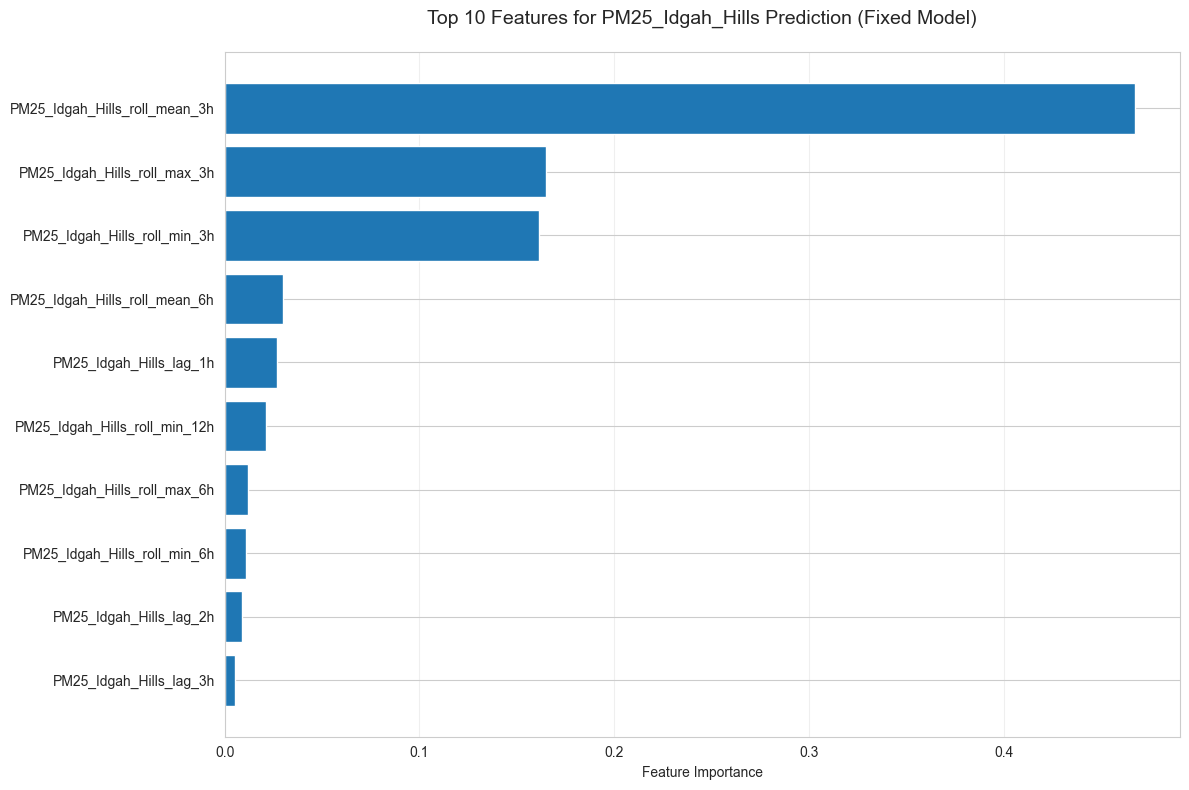

In [15]:
#  ANALYZE FEATURE IMPORTANCE 
print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS (FIXED MODEL)")
print("="*70)

"""
WHAT WE WANT TO SEE NOW:
1. Weather features should be important (they CAUSE pollution)
2. Lag features should be important (pollution persists)
3. Time patterns should be moderate (diurnal/seasonal patterns)
4. NO single feature should dominate (>50% importance)
"""

# Analyze PM2.5 model as example
target = 'PM25_Idgah_Hills'
model = xgb_fixed_models[target]

# Get feature importance
importance = pd.DataFrame({
    'feature': all_safe_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n📈 TOP 15 FEATURES FOR {target}:")
print("-" * 60)
for i, (feature, imp) in enumerate(zip(importance['feature'][:15], importance['importance'][:15]), 1):
    print(f"{i:2d}. {feature:<30} {imp:.4f}")
print("-" * 60)

# Check for problematic patterns
print("\n🔍 HEALTH CHECK:")
top_feature = importance.iloc[0]
if top_feature['importance'] > 0.3:
    print(f"⚠️  WARNING: {top_feature['feature']} has {top_feature['importance']:.1%} importance")
    print("   Consider if this feature might still be leaking information")
else:
    print("✅ Good: No single feature dominates")

# Count feature types in top 20
top_20 = importance.head(20)
weather_in_top = sum(1 for f in top_20['feature'] if f in WEATHER_FEATURES)
lag_in_top = sum(1 for f in top_20['feature'] if '_lag_' in f)
time_in_top = sum(1 for f in top_20['feature'] if f in CYCLICAL_FEATURES + DERIVED_FEATURES)

print(f"\n📊 FEATURE TYPE DISTRIBUTION IN TOP 20:")
print(f"  Weather features: {weather_in_top}")
print(f"  Lag features:     {lag_in_top}")
print(f"  Time features:    {time_in_top}")
print(f"  Other features:   {20 - weather_in_top - lag_in_top - time_in_top}")

# Visualization
plt.figure(figsize=(12, 8))
top_10 = importance.head(10)
plt.barh(range(len(top_10)), top_10['importance'])
plt.yticks(range(len(top_10)), top_10['feature'])
plt.xlabel('Feature Importance')
plt.title(f'Top 10 Features for {target} Prediction (Fixed Model)', fontsize=14, pad=20)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


VISUALIZING PREDICTIONS


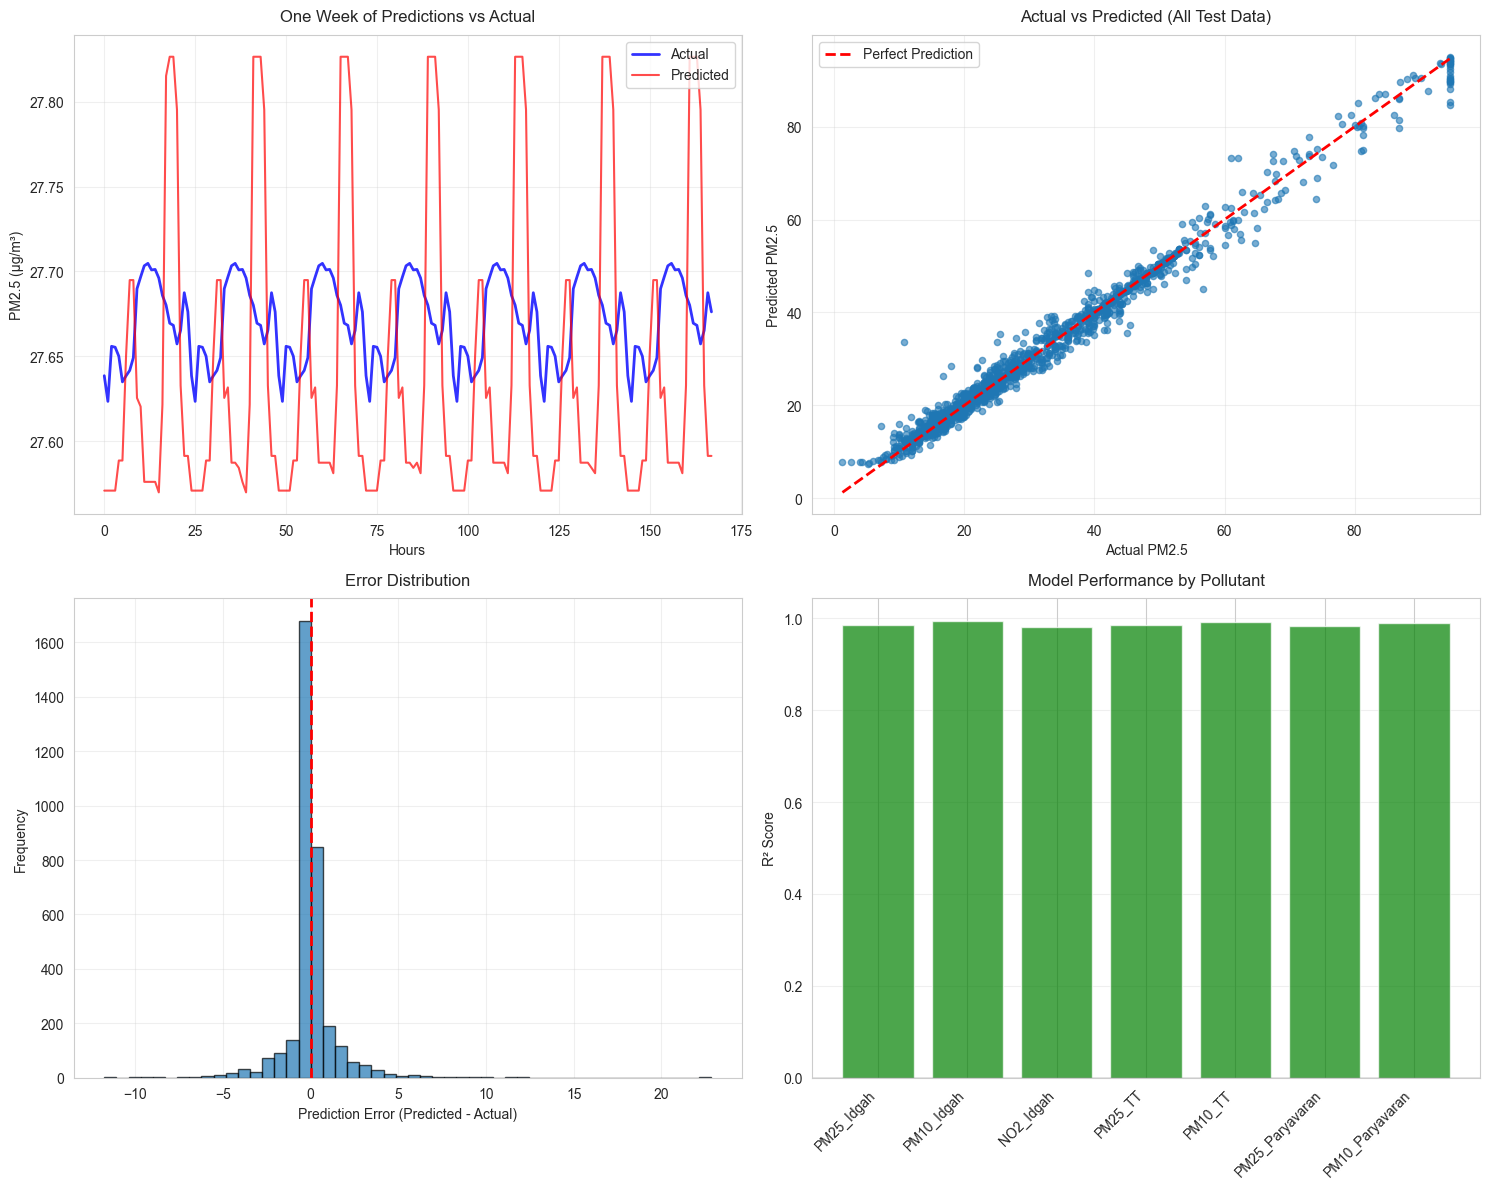

📈 VISUALIZATION INTERPRETATION:
1. Time Series: Predictions should follow actual trends
2. Scatter Plot: Points should cluster along diagonal line
3. Error Histogram: Should be centered at 0 (no bias)
4. Performance Chart: Green bars = good, Red bars = poor


In [16]:
#  VISUALIZE PREDICTIONS vs ACTUAL 
print("\n" + "="*70)
print("VISUALIZING PREDICTIONS")
print("="*70)

# Let's look at PM2.5 predictions
target = 'PM25_Idgah_Hills'
model = xgb_fixed_models[target]
predictions = model.predict(X_test_safe)
actual = y_test[target].values

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Time series (one week)
axes[0, 0].plot(actual[:168], 'b-', label='Actual', linewidth=2, alpha=0.8)
axes[0, 0].plot(predictions[:168], 'r-', label='Predicted', linewidth=1.5, alpha=0.7)
axes[0, 0].set_xlabel('Hours')
axes[0, 0].set_ylabel('PM2.5 (µg/m³)')
axes[0, 0].set_title('One Week of Predictions vs Actual', fontsize=12, pad=10)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Scatter plot
axes[0, 1].scatter(actual, predictions, alpha=0.6, s=20)
axes[0, 1].plot([actual.min(), actual.max()], 
                [actual.min(), actual.max()], 
                'r--', linewidth=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual PM2.5')
axes[0, 1].set_ylabel('Predicted PM2.5')
axes[0, 1].set_title('Actual vs Predicted (All Test Data)', fontsize=12, pad=10)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Error distribution
errors = predictions - actual
axes[1, 0].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Prediction Error (Predicted - Actual)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Error Distribution', fontsize=12, pad=10)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Model comparison by pollutant
r2_values = [res['test_r2'] for res in xgb_results]
pollutants_short = [t.split('_')[0] + '_' + t.split('_')[1] for t in PRIMARY_TARGETS]

colors = ['green' if r2 > 0.6 else 'orange' if r2 > 0.3 else 'red' for r2 in r2_values]
axes[1, 1].bar(range(len(r2_values)), r2_values, color=colors, alpha=0.7)
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
axes[1, 1].set_xticks(range(len(r2_values)))
axes[1, 1].set_xticklabels(pollutants_short, rotation=45, ha='right')
axes[1, 1].set_ylabel('R² Score')
axes[1, 1].set_title('Model Performance by Pollutant', fontsize=12, pad=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("📈 VISUALIZATION INTERPRETATION:")
print("1. Time Series: Predictions should follow actual trends")
print("2. Scatter Plot: Points should cluster along diagonal line")
print("3. Error Histogram: Should be centered at 0 (no bias)")
print("4. Performance Chart: Green bars = good, Red bars = poor")